<a href="https://colab.research.google.com/github/taskeen-mustafa786/Iris-classification-using-knn/blob/html-css-js/Iris%20Classification%20using%20KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load the Iris Dataset

In [ ]:
iris = load_iris()
X = iris.data
y = iris.target

# Convert to DataFrame for better inspection (optional)
iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df['species'] = iris.target_names[y]

print("First 5 rows of the Iris dataset:")
display(iris_df.head())
print("\nTarget names:", iris.target_names)

First 5 rows of the Iris dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Target names: ['setosa' 'versicolor' 'virginica']


### 2. Split the Dataset into Training and Testing Sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 105 samples
Test set size: 45 samples


### 3. Train the K-Nearest Neighbors (KNN) Model

In [ ]:
# Initialize KNN classifier (let's start with k=5)
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train, y_train)

print("KNN model trained successfully with k=5.")

KNN model trained successfully with k=5.


### 4. Evaluate the Model using the Test Set

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45


Confusion Matrix:


,setosa,versicolor,virginica
setosa,15,0,0
versicolor,0,15,0
virginica,0,1,14


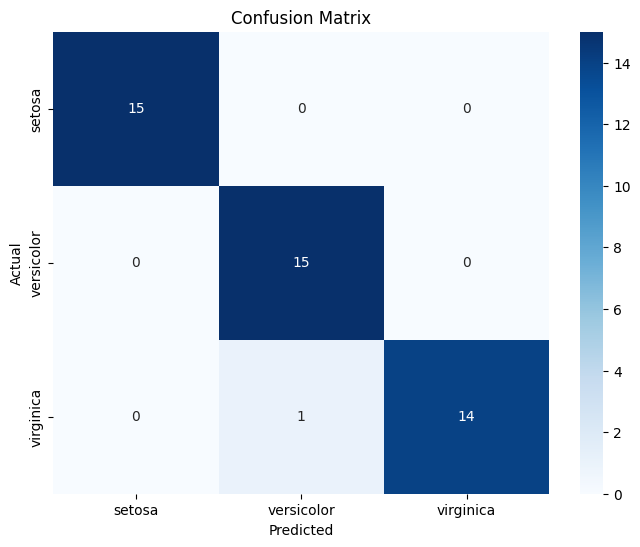

In [ ]:
y_pred = knn.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
display(pd.DataFrame(cm, index=iris.target_names, columns=iris.target_names))

# Plotting the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()